## Waste Classification using CNN Model



In [6]:
%pip install numpy pandas matplotlib seaborn opencv-python pillow scikit-learn tensorflow tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
#Importing necessary libraries

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import cv2

from tqdm import tqdm

import warnings

warnings.filterwarnings('ignore')

In [8]:
train_path = "dataset/TRAIN"

test_path = "dataset/TEST"

In [9]:
#Importing Libraries

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization

from tensorflow.keras.preprocessing. image import ImageDataGenerator, img_to_array, load_img

from tensorflow.keras.utils import plot_model

from glob import glob

In [10]:
import os
import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm

x_data = []
y_data = []

for category in glob(train_path + '/*'):

    for file in tqdm(glob(category + '/*')):

        img_array = cv2.imread(file)

        # Skip unreadable images
        if img_array is None:
            print("Skipping:", file)
            continue

        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        x_data.append(img_array)

        y_data.append(os.path.basename(category))

data = pd.DataFrame({
    'image': x_data,
    'label': y_data
})

print("Total Images:", len(data))
print(data['label'].value_counts())

  1%|          | 79/10000 [00:00<00:25, 384.09it/s]

Skipping: dataset/TRAIN\R\r


100%|██████████| 10000/10000 [00:28<00:00, 345.82it/s]


Total Images: 22564
label
O    12565
R     9999
Name: count, dtype: int64


In [11]:
data.shape

(22564, 2)

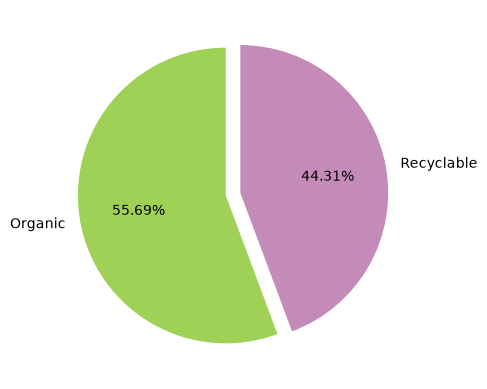

In [12]:
colors = ['#a0d157', '#c48bb8']

plt.pie(data.label.value_counts(), labels=['Organic', 'Recyclable'], autopct='%0.2f%%', colors = colors, startangle = 90 , explode = [0.05, 0.05])
plt.show()

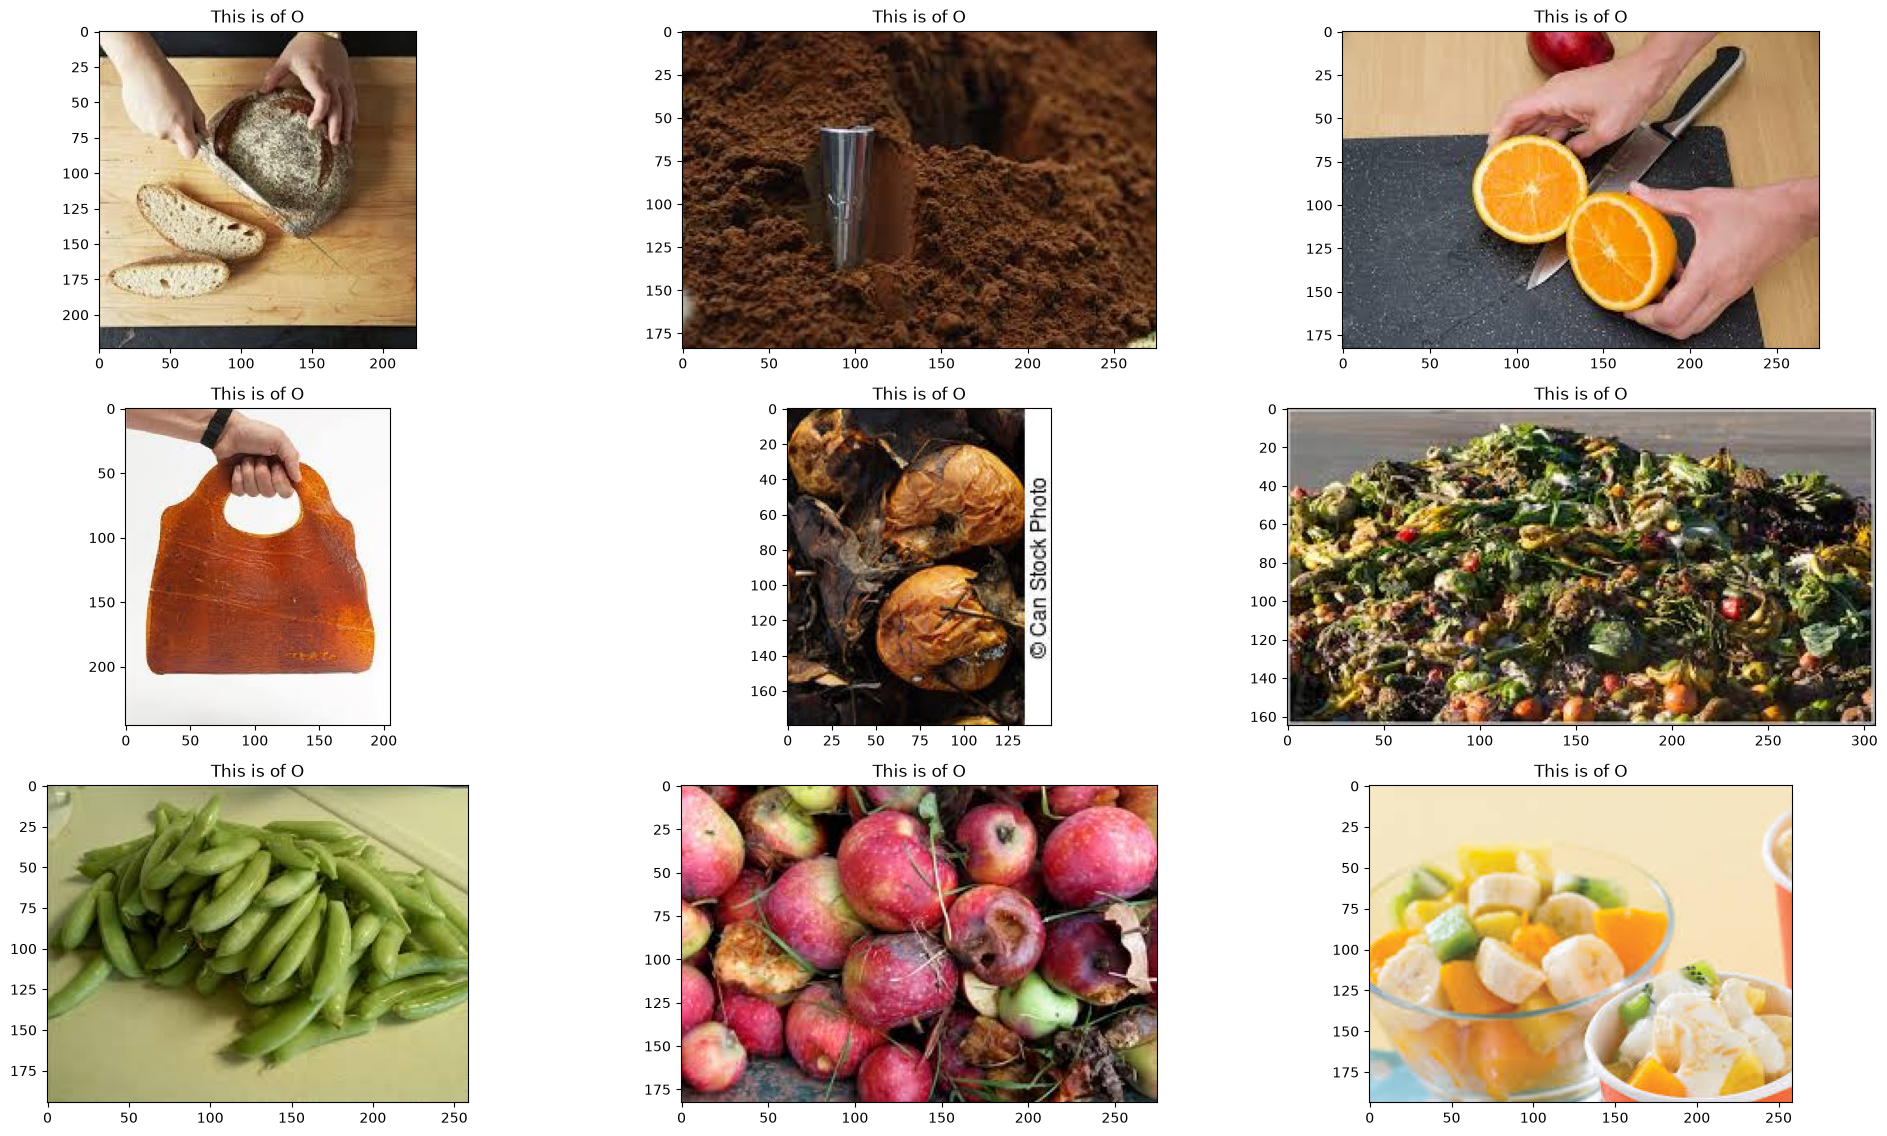

In [13]:
plt.figure(figsize = (20, 15))

for i in range(9):

    plt.subplot(4, 3, (i%12)+1)

    index = np.random.randint(15000)

    plt.title('This is of {0}'. format(data.label[index]))

    plt.imshow(data.image[index])

    plt.tight_layout()

In [14]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256))
model.add(Activation ('relu'))
model.add(Dropout (0.5))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(2))
model.add(Activation('sigmoid'))

model.compile(loss = "binary_crossentropy",
                optimizer = "adam",
                 metrics = ["accuracy"])

batch_size=256

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,261,250 (84.92 MB)

 Trainable params: 22,261,250 (84.92 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
train_datagen = ImageDataGenerator(rescale = 1./255)

In [18]:
test_datagen = ImageDataGenerator(rescale = 1./255)

In [19]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size = (224, 224),
    batch_size = batch_size,
    color_mode = "rgb",
    class_mode = "categorical")

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size = (224, 224), 
    batch_size = batch_size,
    color_mode  = "rgb",
    class_mode = "categorical")

Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [20]:
hist = model.fit(

    train_generator,

    epochs=3,

    validation_data = 
    
    test_generator
)

Epoch 1/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.7629 - loss: 0.5284 - val_accuracy: 0.8667 - val_loss: 0.3744
Epoch 2/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 306s 3s/step - accuracy: 0.8305 - loss: 0.4142 - val_accuracy: 0.8850 - val_loss: 0.3340
Epoch 3/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.8510 - loss: 0.3693 - val_accuracy: 0.8699 - val_loss: 0.3102


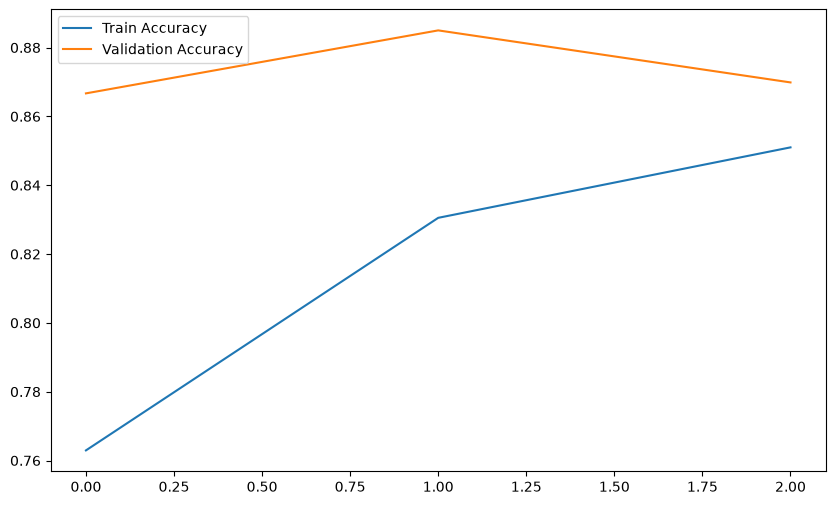

In [22]:
plt.figure(figsize=(10,6))

plt.plot(hist.history ['accuracy'], label ='Train Accuracy')

plt.plot(hist.history ['val_accuracy'], label='Validation Accuracy')

plt.legend()

plt.show()

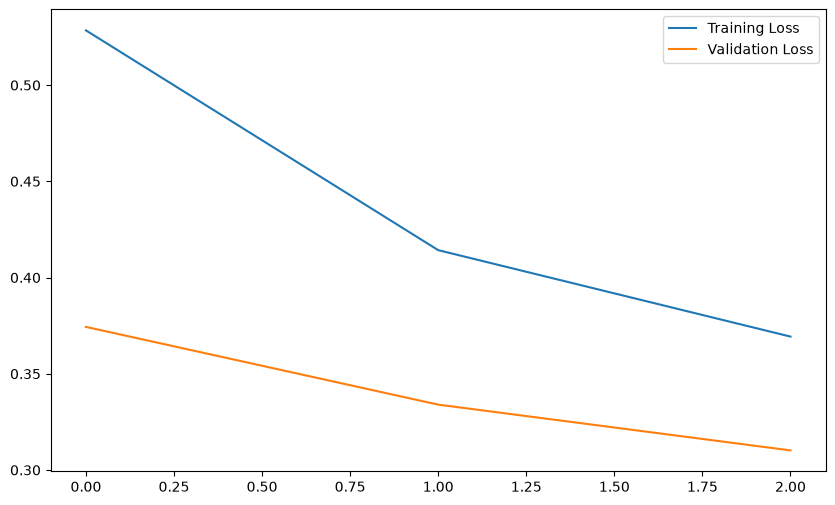

In [23]:
plt.figure(figsize=(10,6))

plt.plot(hist.history['loss'], label='Training Loss')

plt.plot(hist.history ['val_loss'], label= 'Validation Loss')

plt.legend()

plt.show()

In [32]:
def predict_fun(img):

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = np.reshape(img, (-1,224,224,3))

    result = np.argmax(model.predict(img, verbose=0))

    if result == 0:
        print("The image shown is Recyclable Waste")
    else:
        print("The image shown is Organic Waste")

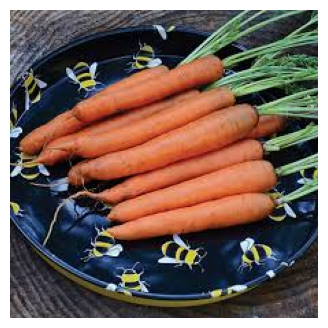

The image shown is Organic Waste


In [33]:
test_img = cv2.imread(r"test.jpg")
predict_fun(test_img)